In [1]:
# Author: Arthur Prigent
# Email: arthur.prigent@univ-brest.fr

In [2]:
import matplotlib.patches as mpatches
from scipy.stats import pearsonr
import matplotlib.ticker as mticker
import cartopy.crs as ccrs
import cartopy
import matplotlib
import scipy
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

import matplotlib.colors as mcolors

from datetime import datetime, timedelta
import cartopy.feature as cfeature
import numpy as np
import xarray as xr
import glob
import matplotlib.pyplot as plt
import cmocean
import netCDF4
import string
import matplotlib.path as mpath
import ArcTools as Atools
import pandas as pd


# define boxes

In [3]:

boxes = pd.read_csv('/home/aprigent/Documents/Projects/Analysis_obs/Arctic_design_10m_150_test_new.csv')



xc150 = np.array(([boxes["Longitude 1"].values,boxes["Longitude 2"].values,
                   boxes["Longitude 2"].values,boxes["Longitude 1"].values,boxes["Longitude 1"].values])).T
yc150 = np.array(([boxes["Latitude 1"].values,boxes["Latitude 1"].values,
                   boxes["Latitude 2"].values,boxes["Latitude 2"].values,boxes["Latitude 1"].values])).T
box_id = np.array(boxes["Box ID"].values)

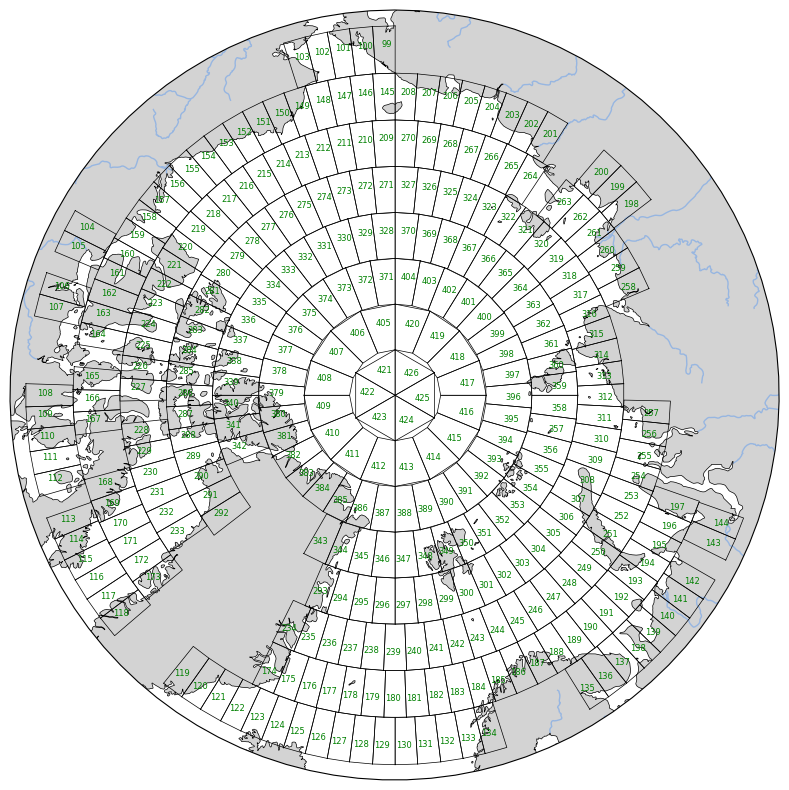

In [4]:
f,ax = plt.subplots(1,1,figsize=[10,10],subplot_kw={'projection':  ccrs.NorthPolarStereo()})
ftz=15


Atools.plot_arctic_ax_map_new(ax,gridlines=False)
for i in range(len(xc150)):
    if np.all(yc150[i] >= 65):
        ax.plot(xc150[i],yc150[i],'k',linewidth=.5, transform=ccrs.PlateCarree())
        ax.text(np.mean(xc150[i]),np.mean(yc150[i]),box_id[i], fontsize=6, color='g',transform=ccrs.PlateCarree(),va='center',ha='center')

# Load profiles

In [5]:
ds_profiles_unique_UDASH = xr.open_dataset('/data0/user/aprigent/PROCESSED/level_1/arctic_profile_UDASH_ISAS_PSAL_new.nc',decode_times=False)
ds_profiles_unique_ITP = xr.open_dataset('/data0/user/aprigent/PROCESSED/level_1/arctic_profile_ITP_ISAS_PSAL_new.nc',decode_times=False)
ds_profiles_unique_ARGO = xr.open_dataset('/data0/user/aprigent/PROCESSED/level_1/arctic_profile_ARGO_ISAS_PSAL_new.nc',decode_times=False)
ds_profiles_unique_NABOS = xr.open_dataset('/data0/user/aprigent/PROCESSED/level_1/arctic_profile_NABOS_ISAS_PSAL_new.nc',decode_times=False)
ds_profiles_unique_BGEP = xr.open_dataset('/data0/user/aprigent/PROCESSED/level_1/arctic_profile_BGEP_ISAS_PSAL_new.nc',decode_times=False)
ds_profiles_unique_ICES = xr.open_dataset('/data0/user/aprigent/PROCESSED/level_1/arctic_profile_ICES_ISAS_PSAL_new.nc',decode_times=False)
ds_profiles_unique_CORA = xr.open_dataset('/data0/user/aprigent/PROCESSED/level_1/arctic_profile_CORA_ISAS_PSAL_new.nc',decode_times=False)
ds_profiles_unique_WOD = xr.open_dataset('/data0/user/aprigent/PROCESSED/level_1/arctic_profile_WOD_ISAS_PSAL_new.nc',decode_times=False)

In [6]:
ds_all = xr.concat([ds_profiles_unique_UDASH,ds_profiles_unique_ITP,
                    ds_profiles_unique_ARGO,ds_profiles_unique_NABOS,
                    ds_profiles_unique_BGEP,ds_profiles_unique_ICES,
                    ds_profiles_unique_CORA,ds_profiles_unique_WOD,
                    ],dim='profile')         

In [7]:
ds_all['profile'] = np.arange(0,ds_all.longitude.shape[0],1)
ds_clean = np.array(ds_all.salinity.values)

# Make statistics per box

In [8]:
from matplotlib.path import Path
import numpy as np

profiles_in_box = {}

for i in range(len(xc150)):

    # build polygon for the box
    polygon = np.column_stack((xc150[i], yc150[i]))
    path = Path(polygon)

    # combine profile coordinates
    points = np.column_stack((ds_all.longitude.values, ds_all.latitude.values))

    # test which profiles fall inside
    inside = path.contains_points(points)

    # store indices of profiles inside the box
    profiles_in_box[box_id[i]] = np.where(inside)[0]
    if len(profiles_in_box[box_id[i]])>0:
        print(f"Box {box_id[i]}: {len(profiles_in_box[box_id[i]])} profiles inside")
counts = [len(profiles_in_box[box_id[i]]) for i in range(len(box_id))]


Box 58: 1 profiles inside
Box 59: 2 profiles inside
Box 60: 1486 profiles inside
Box 61: 42 profiles inside
Box 64: 2 profiles inside
Box 65: 11 profiles inside
Box 71: 208 profiles inside
Box 72: 237 profiles inside
Box 73: 441 profiles inside
Box 74: 218 profiles inside
Box 76: 3 profiles inside
Box 77: 19 profiles inside
Box 78: 256 profiles inside
Box 79: 423 profiles inside
Box 80: 357 profiles inside
Box 81: 323 profiles inside
Box 82: 11 profiles inside
Box 83: 1 profiles inside
Box 84: 99 profiles inside
Box 85: 329 profiles inside
Box 86: 420 profiles inside
Box 87: 492 profiles inside
Box 88: 811 profiles inside
Box 89: 824 profiles inside
Box 90: 366 profiles inside
Box 91: 541 profiles inside
Box 92: 1552 profiles inside
Box 96: 6 profiles inside
Box 97: 4 profiles inside
Box 99: 21 profiles inside
Box 100: 25 profiles inside
Box 101: 182 profiles inside
Box 102: 2179 profiles inside
Box 103: 326 profiles inside
Box 105: 50 profiles inside
Box 106: 40 profiles inside
Box 10

In [9]:
import warnings

warnings.filterwarnings(
    "ignore",
    message="Degrees of freedom <= 0 for slice"
)
    
def plot_profiles_box(ds, mean, std, depth, box_id):

    f, ax = plt.subplots(1,1,figsize=[10,15])

    n_prof = ds.shape[0]

    ax.set_title(
        'Profiles in box ID ' + str(box_id) +
        ' | Number of profiles = ' + str(n_prof)
    )

    # flatten profiles for plotting
    x = ds.ravel()
    y = np.tile(depth, n_prof)

    ax.scatter(x, y, s=1, color='blue',label='Good data')

    # mean and sigma lines
    ax.plot(mean, depth, color='black', label=r'$\mu$')
    ax.plot(mean+std, depth, color='green', linestyle='--', label=r'$\mu + \sigma$')
    ax.plot(mean+2*std, depth, color='orange', linestyle='--', label=r'$\mu + 2\sigma$')
    ax.plot(mean+5*std, depth, color='red', linestyle='--', label=r'$\mu + 5\sigma$')

    ax.plot(mean-std, depth, color='green', linestyle='--', label=r'$\mu - \sigma$')
    ax.plot(mean-2*std, depth, color='orange', linestyle='--', label=r'$\mu - 2\sigma$')
    ax.plot(mean-5*std, depth, color='red', linestyle='--', label=r'$\mu - 5\sigma$')

    # broadcast mean/std to profile dimension
    mean2d = mean[None, :]
    std2d = std[None, :]

    # outliers
    bad_data = (ds > mean2d + 5*std2d) | (ds < mean2d - 5*std2d)

    # plot outliers
    ax.scatter(
        ds[bad_data],
        np.tile(depth, n_prof)[bad_data.ravel()],
        s=4,
        color='red',label='Outliers'
    )

    ax.invert_yaxis()
    ax.set_ylabel('Depth (m)')
    ax.set_xlabel('Salinity')
    ax.legend()

# Apply QC per box ID

In [10]:
def run_qc_pass_outlier(ds_clean, profiles_in_box, n_std1=5, n_std2=5, label="QC"):
    "Renoves the outlier but keep the profile"
    bad_points = {}
    means = {}
    stds = {}

    ds_clean = ds_clean.copy()

    print(f'---- {label} ----')
    for bid, prof_idx in profiles_in_box.items():
        if len(prof_idx) == 0:
            continue

        ds_box = ds_clean[prof_idx, :]

        mean = np.nanmedian(ds_box, axis=0)
        std  = np.nanstd(ds_box, axis=0)

        bad = (ds_box > mean + n_std1 * std) | (ds_box < mean - n_std2 * std)

        print(f"  Box {bid}: removed {np.sum(bad)} points")

        bad_points[bid] = bad
        means[bid] = mean
        stds[bid] = std

        # remove only bad points
        ds_box[bad] = np.nan

        ds_clean[prof_idx, :] = ds_box

    return ds_clean, bad_points, means, stds



ds_clean1, qc1_bad_points, qc1_mean, qc1_std = run_qc_pass_outlier(ds_clean, profiles_in_box, label="1st QC")
ds_clean2, qc2_bad_points, qc2_mean, qc2_std = run_qc_pass_outlier(ds_clean1, profiles_in_box, label="2nd QC")

---- 1st QC ----
  Box 58: removed 0 points
  Box 59: removed 0 points
  Box 60: removed 31 points
  Box 61: removed 0 points
  Box 64: removed 0 points
  Box 65: removed 0 points
  Box 71: removed 3 points
  Box 72: removed 1 points
  Box 73: removed 0 points
  Box 74: removed 2 points
  Box 76: removed 0 points
  Box 77: removed 0 points
  Box 78: removed 59 points
  Box 79: removed 63 points
  Box 80: removed 100 points
  Box 81: removed 0 points
  Box 82: removed 0 points
  Box 83: removed 0 points
  Box 84: removed 0 points
  Box 85: removed 106 points
  Box 86: removed 279 points
  Box 87: removed 403 points
  Box 88: removed 526 points
  Box 89: removed 521 points
  Box 90: removed 116 points
  Box 91: removed 147 points
  Box 92: removed 63 points
  Box 96: removed 0 points
  Box 97: removed 0 points
  Box 99: removed 0 points
  Box 100: removed 0 points
  Box 101: removed 4 points
  Box 102: removed 34 points
  Box 103: removed 7 points
  Box 105: removed 0 points
  Box 106: r

/opt/linux/envs/envs/phyocean-2022.11/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1217: RuntimeWarning: All-NaN slice encountered
  r, k = function_base._ureduce(a, func=_nanmedian, axis=axis, out=out,
/opt/linux/envs/envs/phyocean-2022.11/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1095: RuntimeWarning: All-NaN slice encountered
  result = np.apply_along_axis(_nanmedian1d, axis, a, overwrite_input)


  Box 127: removed 1041 points
  Box 128: removed 1533 points
  Box 129: removed 969 points
  Box 130: removed 1313 points
  Box 131: removed 810 points
  Box 132: removed 994 points
  Box 133: removed 584 points
  Box 134: removed 751 points
  Box 135: removed 0 points
  Box 136: removed 0 points
  Box 137: removed 9 points
  Box 138: removed 0 points
  Box 139: removed 0 points
  Box 140: removed 0 points
  Box 142: removed 0 points
  Box 143: removed 0 points
  Box 144: removed 0 points
  Box 145: removed 0 points
  Box 146: removed 1 points
  Box 147: removed 2 points
  Box 148: removed 6 points
  Box 149: removed 2 points
  Box 150: removed 0 points
  Box 151: removed 11 points
  Box 152: removed 44 points
  Box 153: removed 8 points
  Box 154: removed 76 points
  Box 155: removed 42 points
  Box 156: removed 69 points
  Box 157: removed 65 points
  Box 158: removed 95 points
  Box 159: removed 23 points
  Box 160: removed 0 points
  Box 161: removed 0 points
  Box 162: removed 0 

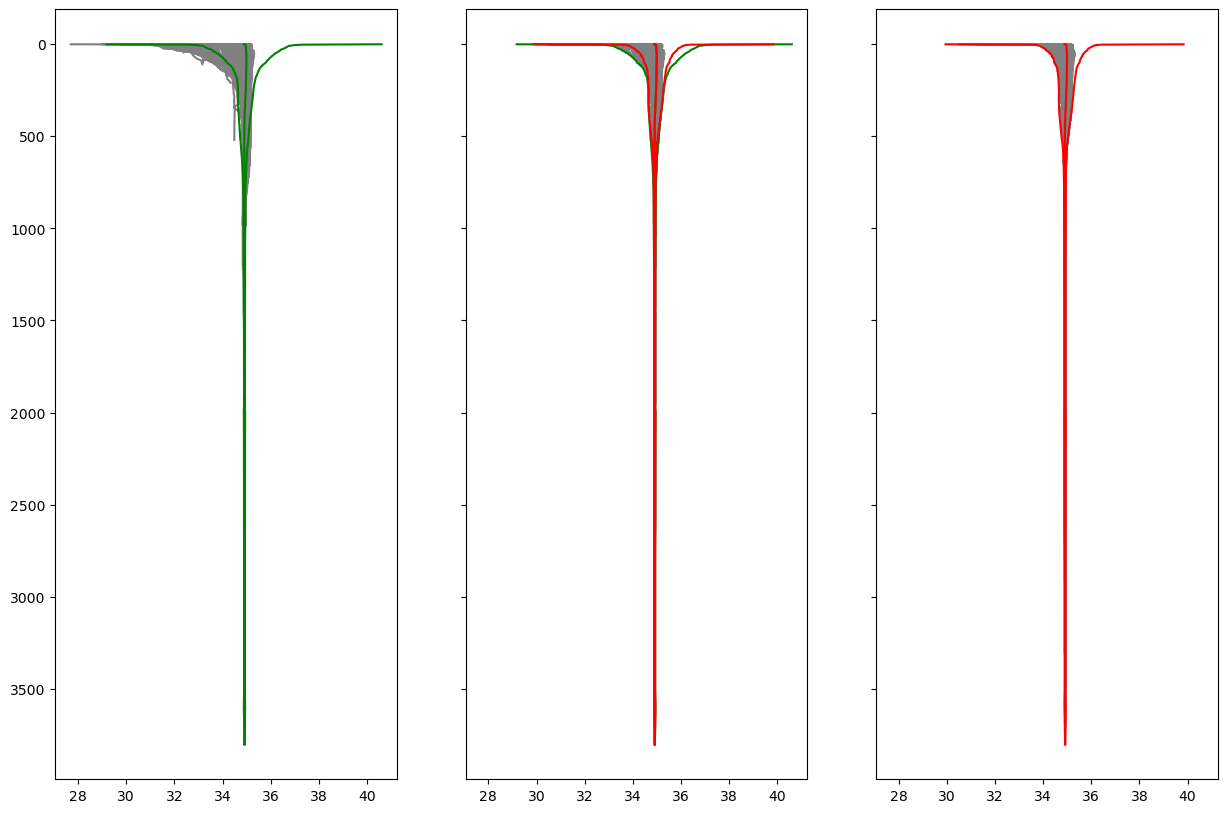

In [11]:
f,ax = plt.subplots(1,3,figsize=[15,10],sharex=True,sharey=True)
ax=ax.ravel()
id_box = 128
ax[0].plot(ds_clean[profiles_in_box[id_box],:].ravel(),
           np.tile(ds_all.depth, profiles_in_box[id_box].shape),color='grey')
ax[0].plot(qc1_mean[id_box],ds_all.depth,color='green')
ax[0].plot(qc1_mean[id_box]+5*qc1_std[id_box],ds_all.depth,color='green')
ax[0].plot(qc1_mean[id_box]-5*qc1_std[id_box],ds_all.depth,color='green')


ax[1].plot(ds_clean1[profiles_in_box[id_box],:].ravel(),
           np.tile(ds_all.depth, profiles_in_box[id_box].shape),color='grey')
ax[1].invert_yaxis()
ax[1].plot(qc1_mean[id_box],ds_all.depth,color='green')
ax[1].plot(qc1_mean[id_box]+5*qc1_std[id_box],ds_all.depth,color='green')
ax[1].plot(qc1_mean[id_box]-5*qc1_std[id_box],ds_all.depth,color='green')


ax[1].plot(qc2_mean[id_box],ds_all.depth,color='red')
ax[1].plot(qc2_mean[id_box]+5*qc2_std[id_box],ds_all.depth,color='red')
ax[1].plot(qc2_mean[id_box]-5*qc2_std[id_box],ds_all.depth,color='red')




ax[2].plot(ds_clean2[profiles_in_box[id_box],:].ravel(),
           np.tile(ds_all.depth, profiles_in_box[id_box].shape),color='grey')

ax[2].plot(qc2_mean[id_box],ds_all.depth,color='red')
ax[2].plot(qc2_mean[id_box]+5*qc2_std[id_box],ds_all.depth,color='red')
ax[2].plot(qc2_mean[id_box]-5*qc2_std[id_box],ds_all.depth,color='red')

In [12]:
ds_qc1 = ds_all.copy()
ds_qc1["salinity_QC"] = (("profile", "depth"), ds_clean2)
ds_qc1

<xarray.Dataset>
Dimensions:        (profile: 311077, depth: 187)
Coordinates:
  * profile        (profile) int64 0 1 2 3 4 ... 311073 311074 311075 311076
  * depth          (depth) float64 1.0 3.0 5.0 10.0 ... 5.3e+03 5.4e+03 5.5e+03
Data variables:
    longitude      (profile) float64 26.25 3.03 24.85 ... -61.18 -61.19 -60.46
    latitude       (profile) float64 79.16 80.3 80.44 80.6 ... 66.6 66.6 66.67
    time           (profile) float64 7.23e+05 7.23e+05 ... 7.392e+05 7.392e+05
    source         (profile) object 'UDASH' 'UDASH' 'UDASH' ... 'WOD' 'WOD'
    dataset_index  (profile) float64 0.0 1.0 2.0 ... 3.291e+04 3.29e+04 3.29e+04
    is_duplicate   (profile) float64 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
    salinity       (profile, depth) float64 nan 32.92 32.92 ... nan nan nan
    sum_salinity   (profile) float64 3.782e+03 1.604e+03 ... 2.981e+03 1.717e+04
    sum_depth      (profile) float64 1.208e+04 2.325e+03 ... 4.464e+03 1.318e+05
    nb_depth       (profile) float64 110.0 47.0 28.0 48.0 ... 118.0 93.0 511.0
    salinity_QC    (profile, depth) float64 nan 32.92 32.92 ... nan nan nan
Attributes:
    title:        ARGO salinity profiles
    source:       ARGO
    featureType:  profile
    Comments:     ARGO temperature profiles interpolated on ISAS vertical lev...

In [13]:
mask_valid = ~ds_qc1.salinity_QC.isnull().all(dim="depth")
ds_qc1 = ds_qc1.sel(profile=mask_valid)

In [14]:
# ds_qc1.to_netcdf('/data0/user/aprigent/PROCESSED/level_2/profiles_QC_PSAL_new.nc')

In [15]:
# ds_qc = xr.open_dataset('/data0/user/aprigent/PROCESSED/level_2/profiles_QC_PSAL_new.nc')

In [16]:
# print('Number of outliers flagged: ',(ds_clean.size -
#                                       np.count_nonzero(np.isnan(ds_clean)))-
#                                      (ds_clean2.size -
#                                       np.count_nonzero(np.isnan(ds_clean2))))




# Apply QC per basin

In [17]:
def run_qc_pass_outlier_basin(ds_clean, profiles_in_box, n_std1=5, n_std2=5, label="QC"):
    "Renoves the outlier but keep the profile"
    bad_points = {}
    means = {}
    stds = {}

    ds_clean = ds_clean.copy()

    print(f'---- {label} ----')
    for bid, prof_idx in profiles_in_box.items():
        if len(prof_idx) == 0:
            continue

        ds_box = ds_clean[prof_idx, :]

        mean = np.nanmedian(ds_box, axis=0)
        std  = np.nanstd(ds_box, axis=0)

        bad = (ds_box > mean + n_std1 * std) | (ds_box < mean - n_std2 * std)

        print(f"  Box {bid}: removed {np.sum(bad)} points")

        bad_points[bid] = bad
        means[bid] = mean
        stds[bid] = std

        # remove only bad points
        ds_box[bad] = np.nan

        ds_clean[prof_idx, :] = ds_box

    return ds_clean, bad_points, means, stds


In [18]:

ds_masks = xr.open_dataset('/data0/user/aprigent/mask_regions.nc')

# Interpolate basin mask to profile positions
basin_at_profiles = ds_masks.interp(
    lon=ds_qc1.longitude % 360,
    lat=ds_qc1.latitude,
    method="nearest"
)


In [19]:
profiles_in_basin = {}

for basin_name in basin_at_profiles.data_vars:
    mask = basin_at_profiles[basin_name].values

    # assume mask == 1 means inside basin
    prof_idx = np.where(mask == 1)[0]

    if len(prof_idx) > 0:
        profiles_in_basin[basin_name] = prof_idx

In [20]:



ds_clean_basin, qc1_bad_points_basin, qc1_mean_basin, qc1_std_basin = run_qc_pass_outlier(ds_qc1.salinity_QC.values, profiles_in_basin, label="QC per basin")


---- QC per basin ----


/opt/linux/envs/envs/phyocean-2022.11/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1095: RuntimeWarning: All-NaN slice encountered
  result = np.apply_along_axis(_nanmedian1d, axis, a, overwrite_input)


  Box AMERASIAN: removed 4430 points
  Box AMERASIAN_SHELF: removed 352 points
  Box SIBERIAN_SHELF: removed 30 points
  Box EURASIAN: removed 3901 points
  Box NORDIC: removed 24221 points
  Box BARENTS: removed 15101 points
  Box KARA: removed 65 points
  Box GREEN_SHELF: removed 697 points
  Box BAFFIN: removed 686 points
  Box CANADA: removed 662 points


In [21]:
ds_qc1_basin = ds_qc1.copy()
ds_qc1_basin["salinity_QC"] = (("profile", "depth"), ds_clean_basin)


In [22]:
mask_valid = ~ds_qc1_basin.salinity_QC.isnull().all(dim="depth")
ds_qc1_basin = ds_qc1_basin.sel(profile=mask_valid)

In [23]:
ds_profiles_qc_UDASH = ds_qc1_basin.where(ds_qc1_basin["source"]=='UDASH',drop=True)
ds_profiles_qc_ITP = ds_qc1_basin.where(ds_qc1_basin["source"]=='ITP',drop=True)
ds_profiles_qc_ARGO = ds_qc1_basin.where(ds_qc1_basin["source"]=='ARGO',drop=True)
ds_profiles_qc_NABOS = ds_qc1_basin.where(ds_qc1_basin["source"]=='NABOS_ctd',drop=True)
ds_profiles_qc_BGEP = ds_qc1_basin.where(ds_qc1_basin["source"]=='BGEP_ctd',drop=True)
ds_profiles_qc_ICES = ds_qc1_basin.where(ds_qc1_basin["source"]=='ICES',drop=True)
ds_profiles_qc_CORA = ds_qc1_basin.where(ds_qc1_basin["source"]=='CORA',drop=True)
ds_profiles_qc_WOD = ds_qc1_basin.where(ds_qc1_basin["source"]=='WOD',drop=True)

In [24]:
ds_profiles_qc_UDASH['profile'] = np.arange(0,ds_profiles_qc_UDASH.longitude.shape[0],1)
ds_profiles_qc_ITP['profile'] = np.arange(0,ds_profiles_qc_ITP.longitude.shape[0],1)
ds_profiles_qc_ARGO['profile'] = np.arange(0,ds_profiles_qc_ARGO.longitude.shape[0],1)
ds_profiles_qc_NABOS['profile'] = np.arange(0,ds_profiles_qc_NABOS.longitude.shape[0],1)
ds_profiles_qc_BGEP['profile'] = np.arange(0,ds_profiles_qc_BGEP.longitude.shape[0],1)
ds_profiles_qc_ICES['profile'] = np.arange(0,ds_profiles_qc_ICES.longitude.shape[0],1)
ds_profiles_qc_CORA['profile'] = np.arange(0,ds_profiles_qc_CORA.longitude.shape[0],1)
ds_profiles_qc_WOD['profile'] = np.arange(0,ds_profiles_qc_WOD.longitude.shape[0],1)


In [25]:
ds_profiles_qc_UDASH.to_netcdf('/data0/user/aprigent/PROCESSED/level_2/arctic_qc_UDASH_ISAS_PSAL_new.nc')
ds_profiles_qc_ITP.to_netcdf('/data0/user/aprigent/PROCESSED/level_2/arctic_qc_ITP_ISAS_PSAL_new.nc')
ds_profiles_qc_ARGO.to_netcdf('/data0/user/aprigent/PROCESSED/level_2/arctic_qc_ARGO_ISAS_PSAL_new.nc')
ds_profiles_qc_NABOS.to_netcdf('/data0/user/aprigent/PROCESSED/level_2/arctic_qc_NABOS_ISAS_PSAL_new.nc')
ds_profiles_qc_BGEP.to_netcdf('/data0/user/aprigent/PROCESSED/level_2/arctic_qc_BGEP_ISAS_PSAL_new.nc')
ds_profiles_qc_ICES.to_netcdf('/data0/user/aprigent/PROCESSED/level_2/arctic_qc_ICES_ISAS_PSAL_new.nc')
ds_profiles_qc_CORA.to_netcdf('/data0/user/aprigent/PROCESSED/level_2/arctic_qc_CORA_ISAS_PSAL_new.nc')
ds_profiles_qc_WOD.to_netcdf('/data0/user/aprigent/PROCESSED/level_2/arctic_qc_WOD_ISAS_PSAL_new.nc')

In [26]:
ds_qc1_basin.to_netcdf('/data0/user/aprigent/PROCESSED/level_2/profiles_QC_PSAL_new.nc')

In [25]:
ds_masks = xr.open_dataset('/data0/user/aprigent/mask_regions.nc')

# Interpolate basin mask to profile positions
basin_at_profiles_qc = ds_masks.interp(
    lon=ds_qc1_basin.longitude % 360,
    lat=ds_qc1_basin.latitude,
    method="nearest"
)
ds_qc1_basin_amerasian = ds_qc1_basin.where(basin_at_profiles_qc.AMERASIAN==1,drop=True)

In [26]:
ds_masks = xr.open_dataset('/data0/user/aprigent/mask_regions.nc')

# Interpolate basin mask to profile positions
basin_at_profiles_qc = ds_masks.interp(
    lon=ds_all.longitude % 360,
    lat=ds_all.latitude,
    method="nearest"
)

ds_all_basin_amerasian = ds_all.where(basin_at_profiles_qc.AMERASIAN==1,drop=True)



In [27]:
ds_masks = xr.open_dataset('/data0/user/aprigent/mask_regions.nc')

# Interpolate basin mask to profile positions
basin_at_profiles_qc1 = ds_masks.interp(
    lon=ds_qc1.longitude % 360,
    lat=ds_qc1.latitude,
    method="nearest"
)

ds_qc1_amerasian = ds_qc1.where(basin_at_profiles_qc1.AMERASIAN==1,drop=True)





In [28]:

    
def plot_vertical_distribution(ax,ds_psal):

    ftz = 15

    sal = ds_psal.values
    depth = ds_psal.depth.values
    n_prof_psal = sal.shape[0]

    finite_per_level_psal = np.sum(np.isfinite(sal), axis=0)
    psal_mean = np.nanmedian(sal, axis=0)
    psal_std = np.nanstd(sal, axis=0)

    ax.scatter(
        sal.ravel(),
        np.tile(depth, n_prof_psal),
        s=1,
        color='blue'
    )

    ax.plot(psal_mean, depth, color='red', label=r'Median')
    ax.plot(psal_mean + psal_std, depth, 'g--', label=r'Median $\pm \sigma$')
    ax.plot(psal_mean - psal_std, depth, 'g--')
    ax.plot(psal_mean + 5*psal_std, depth, 'r--', label=r'Median $\pm 5\sigma$')
    ax.plot(psal_mean - 5*psal_std, depth, 'r--')
    ax.invert_yaxis()
    ax.set_ylim([3000, 0])
    ax.legend(fontsize=ftz)
    ax.set_xlabel("Salinity",fontsize=ftz)
    ax.set_ylabel("Depth (m)",fontsize=ftz)
    ax.tick_params(labelsize=ftz)

   

def plot_vertical_distribution_test(ax, ds_psal):
    ftz = 15
    sal = ds_psal.values
    depth = ds_psal.depth.values
    n_prof_psal = sal.shape[0]

    finite_per_level_psal = np.sum(np.isfinite(sal), axis=0)
    psal_mean = np.nanmedian(sal, axis=0)
    psal_std = np.nanstd(sal, axis=0)

    # --- Fast scatter: flatten and drop NaNs before plotting ---
    sal_flat = sal.ravel()
    depth_flat = np.tile(depth, n_prof_psal)
    finite_mask = np.isfinite(sal_flat)
    ax.scatter(
        sal_flat[finite_mask],
        depth_flat[finite_mask],
        s=1,
        color='blue',
        alpha=0.3,
        rasterized=True,   # renders as bitmap, huge speedup for saving
        linewidths=0,       # skip edge drawing on each marker
    )

    ax.plot(psal_mean, depth, color='red', label=r'Median')
    ax.plot(psal_mean + psal_std, depth, 'g--', label=r'Median $\pm \sigma$')
    ax.plot(psal_mean - psal_std, depth, 'g--')
    ax.plot(psal_mean + 5*psal_std, depth, 'r--', label=r'Median $\pm 5\sigma$')
    ax.plot(psal_mean - 5*psal_std, depth, 'r--')

    ax.invert_yaxis()
    ax.set_ylim([3000, 0])
    ax.legend(fontsize=ftz)
    ax.set_xlabel("Salinity", fontsize=ftz)
    # ax.set_ylabel("Depth (m)", fontsize=ftz)
    ax.tick_params(labelsize=ftz) 

/opt/linux/envs/envs/phyocean-2022.11/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1095: RuntimeWarning: All-NaN slice encountered
  result = np.apply_along_axis(_nanmedian1d, axis, a, overwrite_input)


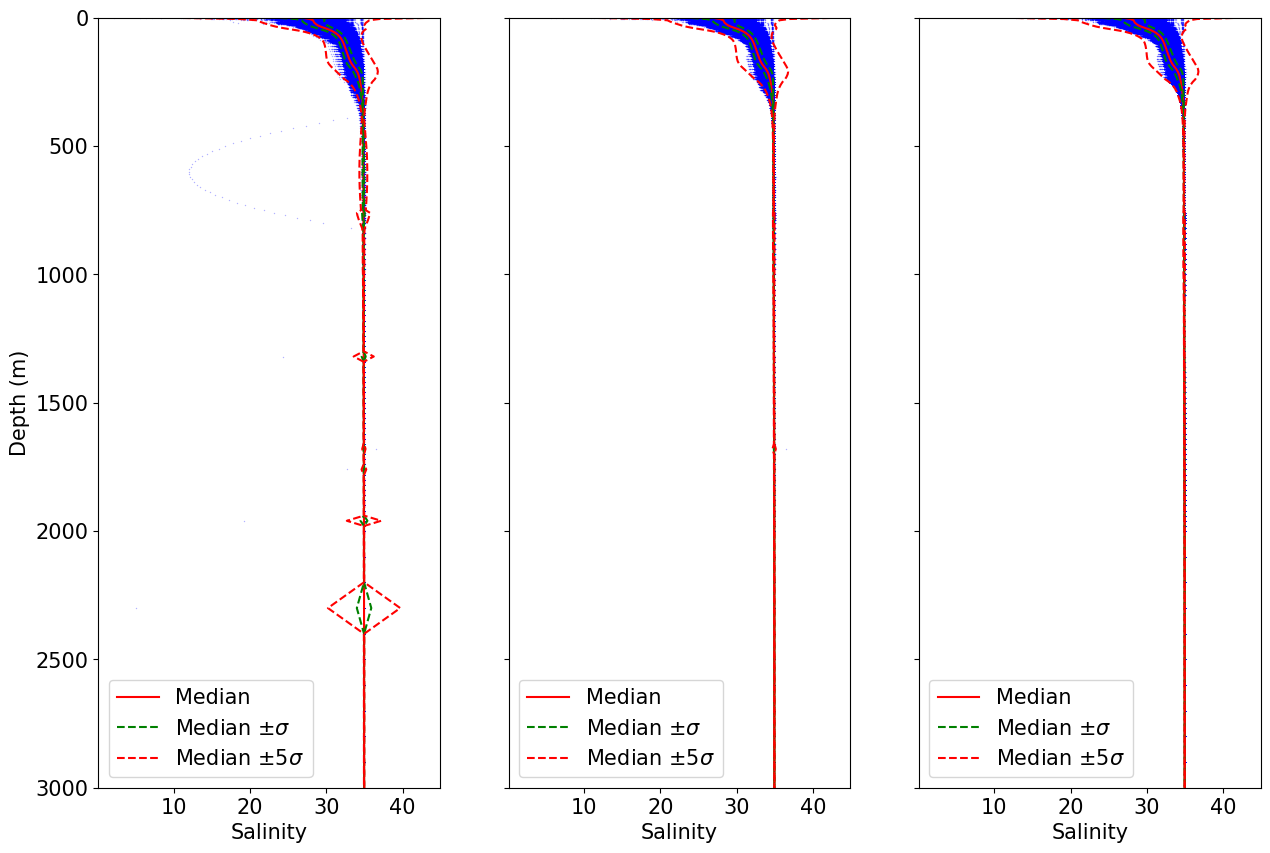

In [29]:
f,ax = plt.subplots(1,3,figsize=[15,10],sharex=True,sharey=True)
ax=ax.ravel()



plot_vertical_distribution_test(ax[0],ds_all_basin_amerasian.salinity)
ax[0].set_ylabel("Depth (m)", fontsize=ftz)
plot_vertical_distribution_test(ax[1],ds_qc1_amerasian.salinity_QC)

plot_vertical_distribution_test(ax[2],ds_qc1_basin_amerasian.salinity_QC)

In [33]:
ds_all.to_netcdf('/data0/user/aprigent/PROCESSED/level_2/profiles_QC_PSAL_new.nc')